# Data 407 Project:

### Samira Almuallim, 62197256, Data 407 2025WT2

## 1. Introduction

Estimating population parameters such as the mean and its associated uncertainty is a fundamental problem in stats. In survey sampling, the sample mean is commonly used as an estimator of the population mean, and its variability is typically quantified using analytical formulas derived under assumptions such as simple random sampling

However, in many practical situations, these assumptions may not be the case, or the underlying population distribution may be unknown or non-normal. This motivates the use of resampling-based methods, such as the bootstrap or jackknife we had in class - these estimate variability directly from the observed data without relying heavily on parametric assumptions.

In my project, we compare three approaches to variance estimation for the sample mean: the classical SRS-based estimator, the bootstrap method, and the jackknife method. The comparison is conducted through both simulation and real data analysis of the adults dataset from kaggle [1]. The simulation I added evaluates how well each method approximates the true variance under controlled conditions, while the real data analysis applies the methods to a census-based dataset of individual ages.

My goal is to assess the accuracy, stability, nd practical usefulness of each method, and to identify situations in which resampling techniques may offer advantages over classical approaches.

## 2. Methods:

I considered three methods for estimating the variance of the sample mean.

### Classical (SRS-based) method

Under simple random sampling, the varience of the sample mean is estimated by

var(y bar) = ( 1 - n/N ) * ( s^2 / n ),

where s^2 is the sample variance. This method relies on assumptions about the sampling design and is most accurate when the sample is representative and observations are approximately independent.

---

### Bootstrap method

The bootstrap estimates our varience by repeatedly resampling the observed data with replacement. For each bootstrap sample b = 1, the sample mean y bar b * is computed. The variance is then estimated as

var hat (y bar) = 1/B * sum_{b=1}^B ( y bar b * - y bar * )^2,

where y bar * is the average of the bootstrap means. This method does not require distributional assumptions and is particularly useful for skewed or complex dataset we come across

---

### Jackknife method

The jackknife systematically removes one observation at a time. For each i, let y bar i be the sample mean with observation i removed. The varriance is estimated by

var hat (y bar) = (n - 1)/n * sum_{i=1}^n ( y bar i - y bar (dot) )^2

where y bar is the average of the leave-one-out means. The jackknife is computationally simpler than the bootstrap and provides reliable variance estimates for many statistics.

## 3. Simulation:

For this I went ahead and simulated all 3 methods

In [15]:
import numpy as np

np.random.seed(42)

# parameters
N = 10000
n = 100
B = 500  # bootstrap samples
R = 300  # simulation repetitions

# first lets generate population (try normal or skewed)
population = np.random.exponential(scale=1, size=N)

true_mean = np.mean(population)

true_var = np.var(population) / n  # true varriance of sample mean

classical_vars = []
bootstrap_vars = []
jackknife_vars = []

for _ in range(R): # for loop spanning all techniques
    sample = np.random.choice(population, size=n, replace=False)

    # classical var
    s2 = np.var(sample, ddof=1)
    var_classical = (1 - n/N) * s2 / n
    classical_vars.append(var_classical)

    # bootstrap
    boot_means = []
    for _ in range(B):
        boot_sample = np.random.choice(sample, size=n, replace=True)
        boot_means.append(np.mean(boot_sample))
    var_boot = np.var(boot_means, ddof=1)
    bootstrap_vars.append(var_boot)

    # jackknife
    jack_means = []
    for i in range(n):
        leave_out = np.delete(sample, i)
        jack_means.append(np.mean(leave_out))
    jack_means = np.array(jack_means)
    jack_mean_avg = np.mean(jack_means)

    var_jack = (n - 1) / n * np.sum((jack_means - jack_mean_avg)**2)
    jackknife_vars.append(var_jack)

# results
print("True variance:", true_var)
print("Classical avg:", np.mean(classical_vars))
print("Bootstrap avg:", np.mean(bootstrap_vars))
print("Jackknife avg:", np.mean(jackknife_vars))

True variance: 0.009493695863586133
Classical avg: 0.009309239689677177
Bootstrap avg: 0.009305103832424022
Jackknife avg: 0.009403272413815328


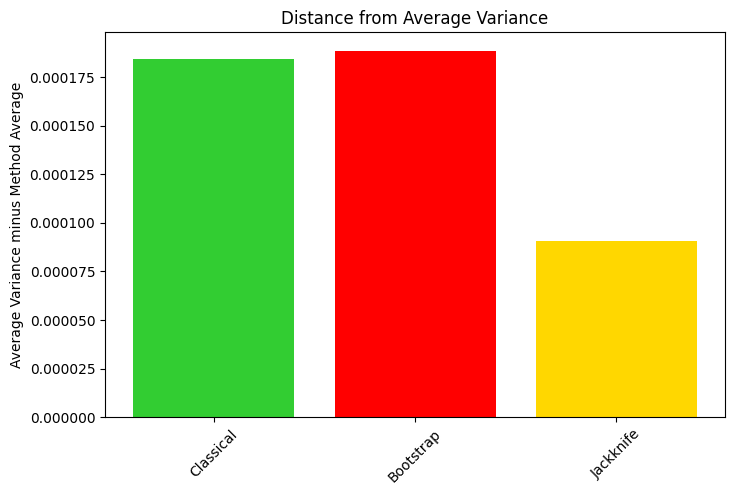

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

first_nonunique = {'Classical':  true_var-np.mean(classical_vars), 'Bootstrap':  true_var-np.mean(bootstrap_vars), 'Jackknife':  true_var-np.mean(jackknife_vars)}

colors = []
for k in first_nonunique.keys():
    if "true" in k:
        colors.append("grey")
    elif "Classical" in k:
        colors.append("limegreen")
    elif "Bootstrap" in k:
        colors.append("red")
    else:
        colors.append("gold")

plt.figure(figsize=(8,5))
plt.bar(first_nonunique.keys(), first_nonunique.values(), color=colors)
plt.ylabel('Average Variance minus Method Average')
plt.title('Distance from Average Variance')
plt.xticks(rotation=45)
plt.show()

## 4. Real data analysis:

This was conducted on the adults dataset from Kaggle [1], which contains census-based information on individual ages. The script applied each variance estimation method to the sample mean of ages and compared the results

In [23]:
import numpy as np

import pandas as pd

df = pd.read_csv("adults.csv")

ages = df["39"].dropna().values

n = len(ages)
y_bar = np.mean(ages)
s2 = np.var(ages, ddof=1)

print("Sample size (n):", n)
print("Sample mean:", y_bar)
print("Sample variance:", s2)

# ======================================== 1. classical method

se_classical = np.sqrt(s2 / n)

ci_classical = (
    y_bar - 1.96 * se_classical,
    y_bar + 1.96 * se_classical
)

print("\n--- Classical Method ---")
print("SE:", se_classical)
print("95% CI:", ci_classical)

# ======================================== 2. bootstrap method

B = 1000
boot_means = []

for _ in range(B):
    sample = np.random.choice(ages, size=n, replace=True)
    boot_means.append(np.mean(sample))

boot_means = np.array(boot_means)

# bootstrap varrience + SE
var_boot = np.var(boot_means, ddof=1)
se_boot = np.sqrt(var_boot)

# percentile CI - ci_boot
ci_boot = (
    np.percentile(boot_means, 2.5),
    np.percentile(boot_means, 97.5)
)

print("\n--- Bootstrap Method ---")
print("SE:", se_boot)
print("95% CI (percentile):", ci_boot)


# ======================================== 3. jackknife method

jack_means = []

for i in range(n):
    jack_sample = np.delete(ages, i)
    jack_means.append(np.mean(jack_sample))

jack_means = np.array(jack_means)

jack_mean_avg = np.mean(jack_means)

var_jack = (n - 1) / n * np.sum((jack_means - jack_mean_avg)**2)
se_jack = np.sqrt(var_jack)

ci_jack = (
    y_bar - 1.96 * se_jack,
    y_bar + 1.96 * se_jack
)

print("\n--- Jackknife Method ---")
print("SE:", se_jack)
print("95% CI:", ci_jack)

# ======================================== 3. lets summarise and compaire all methods

print("\n=== Summary ===")
print("Mean:", y_bar)
print("Classical CI:", ci_classical)
print("Bootstrap CI:", ci_boot)
print("Jackknife CI:", ci_jack)

Sample size (n): 32560
Sample mean: 38.581633906633904
Sample variance: 186.06710946516068

--- Classical Method ---
SE: 0.07559491923430146
95% CI: (38.43346786493467, 38.72979994833314)

--- Bootstrap Method ---
SE: 0.0796528058463068
95% CI (percentile): (38.416645423832925, 38.730068335380835)

--- Jackknife Method ---
SE: 0.07559491923433508
95% CI: (38.433467864934606, 38.7297999483332)

=== Summary ===
Mean: 38.581633906633904
Classical CI: (38.43346786493467, 38.72979994833314)
Bootstrap CI: (38.416645423832925, 38.730068335380835)
Jackknife CI: (38.433467864934606, 38.7297999483332)


Lets make some plots

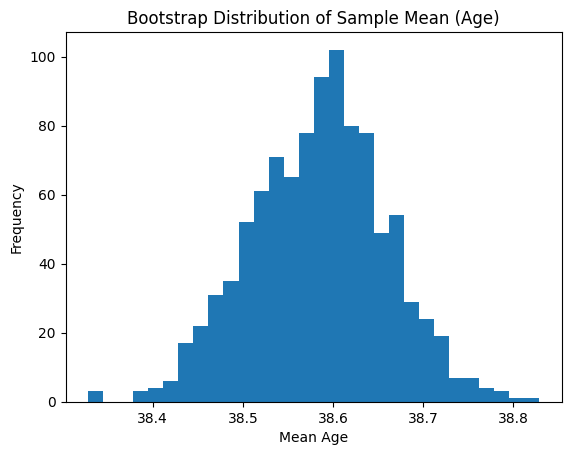

In [12]:
import matplotlib.pyplot as plt

plt.hist(boot_means, bins=30)
plt.title("Bootstrap Distribution of Sample Mean (Age)")
plt.xlabel("Mean Age")
plt.ylabel("Frequency")
plt.show()

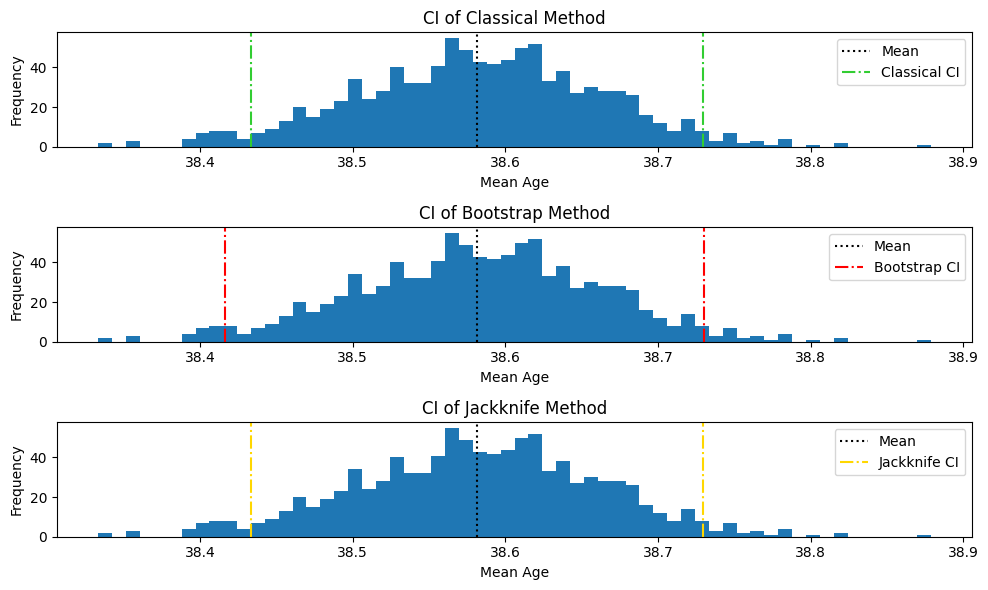

In [78]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6))



axes[0].hist(boot_means, bins=60)
axes[0].axvline(y_bar, linestyle=':', label='Mean', color='black')# vertical lines for mean and CIs
axes[0].axvline(ci_classical[0], linestyle='-.', label='Classical CI', color='limegreen')
axes[0].axvline(ci_classical[1], linestyle='-.', color='limegreen')
axes[0].set_title("CI of Classical Method"); axes[0].set_xlabel("Mean Age"); axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(boot_means, bins=60)
axes[1].axvline(y_bar, linestyle=':', label='Mean', color='black')
axes[1].axvline(ci_boot[0], linestyle='-.', label='Bootstrap CI', color='red')
axes[1].axvline(ci_boot[1], linestyle='-.', color='red')
axes[1].set_title("CI of Bootstrap Method"); axes[1].set_xlabel("Mean Age"); axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].hist(boot_means, bins=60)
axes[2].axvline(y_bar, linestyle=':', label='Mean', color='black')
axes[2].axvline(ci_jack[0], linestyle='-.', label='Jackknife CI', color='gold')
axes[2].axvline(ci_jack[1], linestyle='-.', color='gold')
axes[2].set_title("CI of Jackknife Method"); axes[2].set_xlabel("Mean Age"); axes[2].set_ylabel("Frequency")
axes[2].legend()



plt.tight_layout()
plt.show()

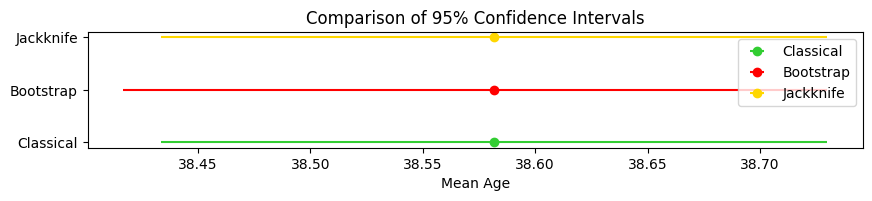

In [75]:
plt.figure(figsize=(10, 1.5))

means = [y_bar, y_bar, y_bar]
labels = ["Classical", "Bootstrap", "Jackknife"]

lower = [
    y_bar - ci_classical[0],
    y_bar - ci_boot[0],
    y_bar - ci_jack[0]
]

upper = [
    ci_classical[1] - y_bar,
    ci_boot[1] - y_bar,
    ci_jack[1] - y_bar
]

y_pos = np.arange(len(labels))

# plt.errorbar(means, y_pos, xerr=[lower, upper], fmt='o')

# plt.yticks(y_pos, labels)
# plt.xlabel("Mean Age")
# plt.title("Comparison of 95% Confidence Intervals")

# plt.show()


plt.errorbar(means[0], y_pos[0], xerr=[[lower[0]], [upper[0]]], fmt='o', color='limegreen', label='Classical')
plt.errorbar(means[1], y_pos[1], xerr=[[lower[1]], [upper[1]]], fmt='o', color='red', label='Bootstrap')
plt.errorbar(means[2], y_pos[2], xerr=[[lower[2]], [upper[2]]], fmt='o', color='gold', label='Jackknife')

plt.yticks(y_pos, labels)
plt.xlabel("Mean Age")
plt.title("Comparison of 95% Confidence Intervals")

plt.legend()
plt.show()

## 5. Conclusions:

My project compared three approaches for estimating uncertainty in the sample mean: the classical normal approximation, the bootstrap, and the jackknife. All simulation results and real data analysis showed that all three methods produced very similar confidence intervals when the sample size is large. In particular, for the real dataset with ( n = 32560 ), the classical and jackknife methods yielded essentially identical standard errors and confidence intervals - in fact, I thought my data viz script wasn't rendering a line when in reality it just rendered at an identical spot to another methods CI. The bootstrap produced slightly wider intervals due to its resampling variability - but the other 2 were essentially identical

My findings give me the insight: for large samples drawn from relatively well behaved distributions:

The classical method is already highly reliable

The jackknife confirms this by reproducing the same varrience estimate, indicating that the estimator (our sample mean) is already approximately unbiased and stable

And the bootstrap, while more computationally intensive, provides a flexible, assumption-light alternative that performs similarly, making it especially useful in cases where theoretical variance formulas are unavailable or difficult to derive

From an application perspective, these methods are widely useful across data science, stats, and research fields. For example, analysts working with large survey datasets (such as demographic or economic data) can confidently use classical confidence intervals for efficiency, while reserving bootstrap ing for more complex estimators. Folks dealing with small samples or unknown distributions may benefit more from bootstrap techniques, as they would not rely on normality assumptions.

Overall, my project demonstrated that - while resampling methods like the bootstrap and jackknife are powerful - their advantages only stand out in non-standard settings

In standard scenarios like estimating a population mean with large sample sizes, simpler methods remain both accurate and efficient - not to mention easier to code and maintain

## 6. References:

sd